In [93]:
import pandas as pd

In [94]:
predicciones = pd.read_csv(
    "predicciones_xgb.csv"
)

In [95]:
predicciones.head()

predicciones.columns

Index(['fecha', 'ct', 'real', 'prediccion'], dtype='object')

In [96]:
# la capacidad del CT es 400Kw, por tanto mas de un 85% se considera saturación
predicciones["aviso_saturacion"] = 400 * 0.85

In [97]:
predicciones["saturado"] = (
    predicciones["prediccion"]
    > predicciones["aviso_saturacion"]
)

In [98]:
predicciones["saturado"].value_counts()

saturado
False    1676
True       43
Name: count, dtype: int64

In [99]:
saturaciones = predicciones[
    predicciones["saturado"]
]

saturaciones.head(20)

,fecha,ct,real,prediccion,aviso_saturacion,saturado
14,2026-03-21 22:00:00,CT-0710,353.708,372.46198,340.0,True
30,2026-03-22 14:00:00,CT-0710,336.614,344.05290,340.0,True
37,2026-03-22 21:00:00,CT-0710,420.015,405.83210,340.0,True
38,2026-03-22 22:00:00,CT-0710,378.077,410.43814,340.0,True
53,2026-03-23 13:00:00,CT-0710,388.497,376.22104,340.0,True
54,2026-03-23 14:00:00,CT-0710,356.222,419.73337,340.0,True
55,2026-03-23 15:00:00,CT-0710,318.460,375.64014,340.0,True
61,2026-03-23 21:00:00,CT-0710,467.946,436.20154,340.0,True
62,2026-03-23 22:00:00,CT-0710,397.405,435.58750,340.0,True
84,2026-03-24 20:00:00,CT-0710,431.006,352.81570,340.0,True


In [100]:
resumen_ct = (
    predicciones
    .groupby("ct")["saturado"]
    .sum()
    .reset_index()
)

resumen_ct.columns = [
    "ct",
    "num_saturaciones"
]

resumen_ct = resumen_ct.sort_values(
    "num_saturaciones",
    ascending=False
)

resumen_ct.head(10)

,ct,num_saturaciones
0,CT-0710,43


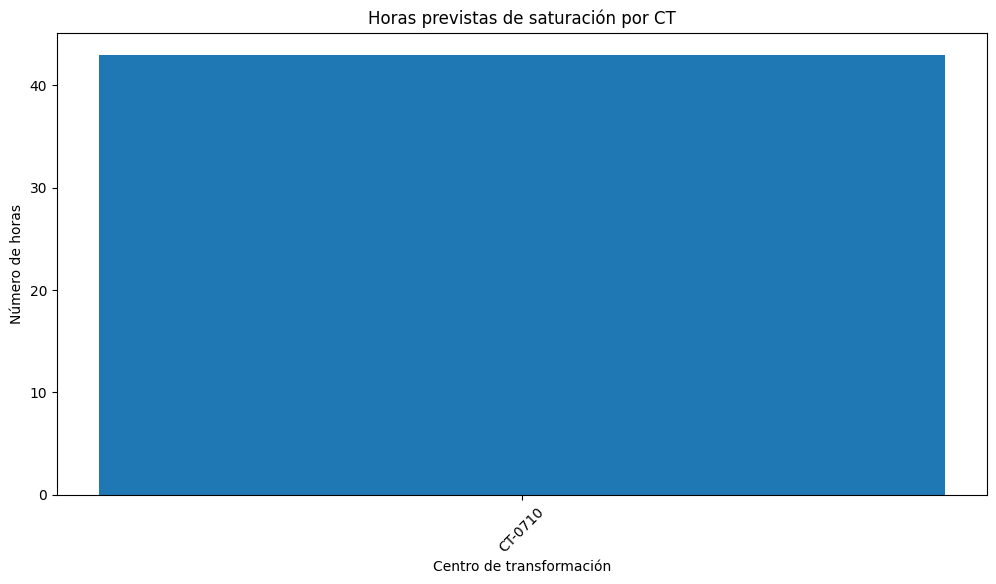

In [101]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    resumen_ct["ct"][:15],
    resumen_ct["num_saturaciones"][:15]
)

plt.title(
    "Horas previstas de saturación por CT"
)

plt.xlabel("Centro de transformación")

plt.ylabel("Número de horas")

plt.xticks(rotation=45)

plt.show()